In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [7]:
# Task 1: Data Quality Check
"""
This section checks:
- Missing values
- Data types
- Duplicate rows
- Outliers detection using IQR
"""

# Load the dataset
df = pd.read_csv(r"C:\Users\ariam\Downloads\archive (6)\SuperMarket Analysis.csv")

# 1. Check for Missing Values

print("Missing Values in Each Column:\n")
print(df.isnull().sum())

# Check percentage of missing values
print("\nPercentage of Missing Values:\n")
print((df.isnull().sum() / len(df)) * 100)



# 2. Check Data Types

print("\nData Types:\n")
print(df.dtypes)



# 3. Check for Duplicate Rows

duplicates = df.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicates)



# 4. Detect Outliers using IQR
# (Detection ONLY - no handling)


# Select numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

print("\nOutliers Detection (using IQR):\n")

for col in numerical_cols:
    # Calculate Q1 (25%) and Q3 (75%)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    # Print number of outliers
    print(f"{col}: {len(outliers)} outliers")

Missing Values in Each Column:

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Percentage of Missing Values:

Invoice ID                 0.0
Branch                     0.0
City                       0.0
Customer type              0.0
Gender                     0.0
Product line               0.0
Unit price                 0.0
Quantity                   0.0
Tax 5%                     0.0
Sales                      0.0
Date                       0.0
Time                       0.0
Payment                    0.0
cogs                       

In [9]:

# Task 2: Handling Missing Values


"""
There are no missing values in the dataset.
However, this demonstrates how to handle missing values
using Mean Imputation if they exist.
"""

df_filled = df.copy()

numerical_cols = df_filled.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    df_filled[col] = df_filled[col].fillna(df_filled[col].mean())

print("Missing values handled using Mean Imputation.")

Missing values handled using Mean Imputation.


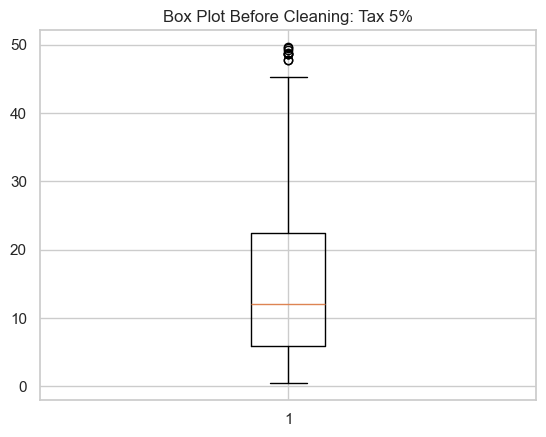

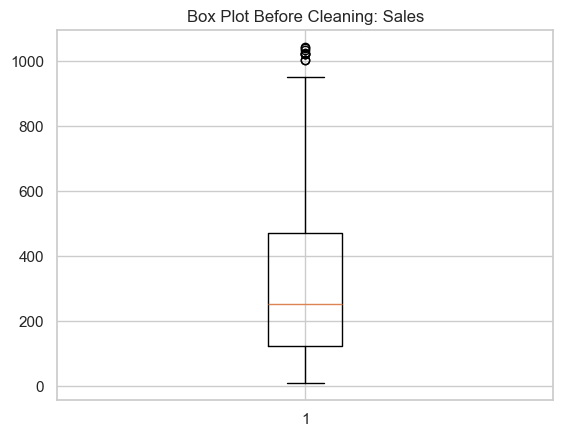

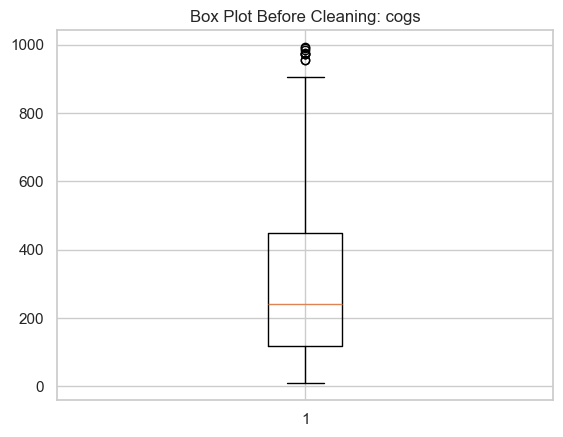

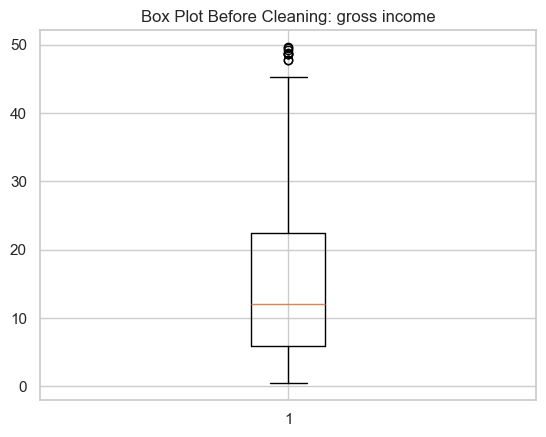

In [13]:


cols_with_outliers = ['Tax 5%', 'Sales', 'cogs', 'gross income']

for col in cols_with_outliers:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Box Plot Before Cleaning: {col}")
    plt.show()

In [14]:

# Task 3: Outliers Handling using IQR


"""
In this task, outliers are removed using the IQR method.
"""

df_clean = df.copy()

# Shape BEFORE cleaning
print("Shape before removing outliers:", df_clean.shape)

numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

#  Shape AFTER cleaning
print("Shape after removing outliers:", df_clean.shape)

Shape before removing outliers: (1000, 17)
Shape after removing outliers: (991, 17)


In [16]:

# Task 4: Normalize Numerical Features


from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select numerical columns from dataset
df_numeric = df_clean.select_dtypes(include=['float64', 'int64'])

# Display first rows
df_numeric.head()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
0,74.69,7,26.1415,548.9715,522.83,4.761905,26.1415,9.1
1,15.28,5,3.8200,80.2200,76.40,4.761905,3.8200,9.6
2,46.33,7,16.2155,340.5255,324.31,4.761905,16.2155,7.4
3,58.22,8,23.2880,489.0480,465.76,4.761905,23.2880,8.4
4,86.31,7,30.2085,634.3785,604.17,4.761905,30.2085,5.3


In [17]:

# Min-Max Normalization


minmax_scaler = MinMaxScaler()

df_minmax = df_clean.copy()

df_minmax[df_numeric.columns] = minmax_scaler.fit_transform(df_numeric)

df_minmax.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,0.718847,0.666667,0.571955,0.571955,1/5/2019,1:08:00 PM,Ewallet,0.571955,0.0,0.571955,0.850000
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,0.057855,0.444444,0.073890,0.073890,3/8/2019,10:29:00 AM,Cash,0.073890,0.0,0.073890,0.933333
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,0.403316,0.666667,0.350474,0.350474,3/3/2019,1:23:00 PM,Credit card,0.350474,0.0,0.350474,0.566667
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,0.535603,0.777778,0.508284,0.508284,1/27/2019,8:33:00 PM,Ewallet,0.508284,0.0,0.508284,0.733333
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,0.848131,0.666667,0.662702,0.662702,2/8/2019,10:37:00 AM,Ewallet,0.662702,0.0,0.662702,0.216667


In [20]:
# Z-score Normalization
zscore_scaler = StandardScaler()

df_zscore = df_clean.copy()

df_zscore[df_numeric.columns] = zscore_scaler.fit_transform(df_numeric)

df_zscore.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,0.737595,0.527206,0.978017,0.978017,1/5/2019,1:08:00 PM,Ewallet,0.978017,0.0,0.978017,1.235531
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,-1.521483,-0.161602,-0.994929,-0.994929,3/8/2019,10:29:00 AM,Cash,-0.994929,0.0,-0.994929,1.526891
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,-0.340800,0.527206,0.100681,0.100681,3/3/2019,1:23:00 PM,Credit card,0.100681,0.0,0.100681,0.244907
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,0.111319,0.871610,0.725803,0.725803,1/27/2019,8:33:00 PM,Ewallet,0.725803,0.0,0.725803,0.827627
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,1.179448,0.527206,1.337490,1.337490,2/8/2019,10:37:00 AM,Ewallet,1.337490,0.0,1.337490,-0.978805


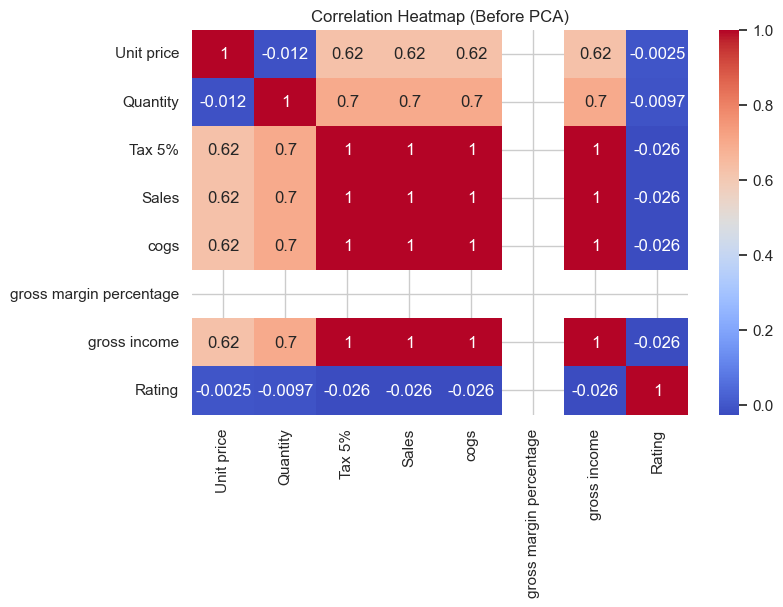

In [19]:

# Correlation Heatmap


plt.figure(figsize=(8, 5))

sns.heatmap(df_numeric.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [21]:
#task5 Applying PCA only if the numerical features show a correlation.
from sklearn.decomposition import PCA


# Use numerical features only
X = df_numeric.copy()

# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.99604927 0.00390948]
Total Explained Variance: 0.999958753596867


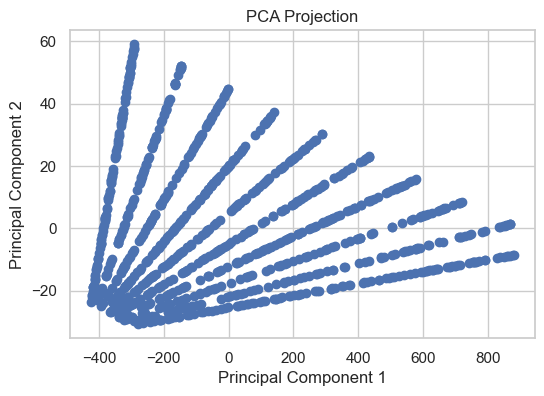

In [22]:
# Visualization of PCA
# Create DataFrame for PCA results
df_pca = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])

# Plot PCA result
plt.figure(figsize=(6, 4))

plt.scatter(df_pca['PC1'], df_pca['PC2'])

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()